# RQ6: Model Robustness and Generalization Analysis

## Research Question
How robust is the selected supervised learning model under different train-test splits, cross-validation settings, or data perturbation scenarios?

## Expected Results
The selected model is expected to maintain relatively stable performance across validation settings and degrade gradually under noisy or incomplete data.

---

In [1]:
# ── Import Required Libraries ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
import warnings

warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully')


✅ All libraries imported successfully


In [2]:
# ── Setup Directories ─────────────────────────────────────────────────────
notebook_dir = Path.cwd()
root_dir = notebook_dir.parent if notebook_dir.name == 'py files' else notebook_dir

DATA_PATH = root_dir / 'data' / 'genz_social_media_usage_1Million.csv'
OUTPUT_DIR = root_dir / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'📁 Data Path: {DATA_PATH}')
print(f'📁 Output Directory: {OUTPUT_DIR}')
print(f'✅ Directories configured')


📁 Data Path: C:\Users\patil\Downloads\ML Project\data\genz_social_media_usage_1Million.csv
📁 Output Directory: C:\Users\patil\Downloads\ML Project\output
✅ Directories configured


In [3]:
# ── Load Dataset ──────────────────────────────────────────────────────────
print('\n📊 Loading Dataset...')
print('=' * 80)

try:
    df = pd.read_csv('genz_social_media_usage_1Million.csv')
    print(f'✅ Data loaded successfully')
    print(f'   Shape: {df.shape}')
    print(f'   Columns: {list(df.columns)}')
    print(f'   Data types:\n{df.dtypes}')
except FileNotFoundError:
    print(f'❌ File not found: {DATA_PATH}')
    print('Using sample data for demonstration...')
    # Create sample data if file not found
    np.random.seed(42)
    df = pd.DataFrame({
        'gender': np.random.choice(['Male', 'Female', 'Non-Binary'], 10000),
        'mental_health_score': np.random.uniform(1, 10, 10000),
        'addiction_level': np.random.choice(['Low', 'Medium', 'High'], 10000),
        'daily_usage_hours': np.random.uniform(1, 12, 10000),
        'age': np.random.randint(13, 25, 10000)
    })
    print(f'✅ Sample data created with shape: {df.shape}')

print(f'\nFirst few rows:')
print(df.head())



📊 Loading Dataset...
❌ File not found: C:\Users\patil\Downloads\ML Project\data\genz_social_media_usage_1Million.csv
Using sample data for demonstration...
✅ Sample data created with shape: (10000, 5)

First few rows:
       gender  mental_health_score addiction_level  daily_usage_hours  age
0  Non-Binary             2.782027             Low           7.234798   14
1        Male             4.942196            High           3.605468   23
2  Non-Binary             4.678694            High           1.158072   20
3  Non-Binary             4.860271             Low           1.229476   14
4        Male             6.270052            High           7.731789   20


In [4]:
# ── Data Preprocessing ────────────────────────────────────────────────────
print('\n🔧 Data Preprocessing...')
print('=' * 80)

# Create a copy for processing
df_processed = df.copy()

# Handle missing values
missing_values = df_processed.isnull().sum()
if missing_values.any():
    print(f'⚠️ Missing values found:\n{missing_values[missing_values > 0]}')
    df_processed = df_processed.dropna()
    print(f'✅ Missing values removed. New shape: {df_processed.shape}')
else:
    print('✅ No missing values found')

# Prepare features and target
# Target: mental_health_score (regression) or addiction_level (classification)
# Features: all numeric columns except target

numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

print(f'\nNumeric columns: {numeric_cols}')
print(f'Categorical columns: {categorical_cols}')

# Select target and features
if 'mental_health_score' in numeric_cols:
    y = df_processed['mental_health_score'].values
    target_type = 'regression'
    print(f'✅ Target: mental_health_score (Regression)')
else:
    y = df_processed['addiction_level'].values if 'addiction_level' in df_processed.columns else None
    target_type = 'classification'
    print(f'✅ Target: addiction_level (Classification)')

# Prepare features - encode categorical variables
X = df_processed.copy()
le_dict = {}

for col in categorical_cols:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le

# Remove target from features
if 'mental_health_score' in X.columns:
    X = X.drop('mental_health_score', axis=1)
if 'addiction_level' in X.columns:
    X = X.drop('addiction_level', axis=1)

# Remove non-numeric columns
X = X.select_dtypes(include=[np.number])

print(f'\n✅ Feature matrix shape: {X.shape}')
print(f'   Features: {list(X.columns)}')
print(f'   Target shape: {y.shape}')

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Features standardized')



🔧 Data Preprocessing...
✅ No missing values found

Numeric columns: ['mental_health_score', 'daily_usage_hours', 'age']
Categorical columns: ['gender', 'addiction_level']
✅ Target: mental_health_score (Regression)

✅ Feature matrix shape: (10000, 3)
   Features: ['gender', 'daily_usage_hours', 'age']
   Target shape: (10000,)
✅ Features standardized


In [5]:
# ── TEST 1: Train-Test Split Robustness ───────────────────────────────────
print('\n' + '=' * 80)
print('TEST 1: TRAIN-TEST SPLIT ROBUSTNESS')
print('=' * 80)
print('Testing model performance across different random train-test splits...\n')

# Use regression model (RandomForestRegressor)
train_test_results = []
n_splits = 10
test_sizes = [0.2, 0.3, 0.4]

for test_size in test_sizes:
    print(f'\nTest Size: {test_size * 100:.0f}%')
    print('-' * 60)
    
    split_results = {
        'test_size': test_size,
        'mse_scores': [],
        'mae_scores': [],
        'r2_scores': [],
        'rmse_scores': []
    }
    
    for i in range(n_splits):
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=test_size, random_state=i
        )
        
        # Train model
        model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        
        # Predict and evaluate
        y_pred = model.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mse)
        
        split_results['mse_scores'].append(mse)
        split_results['mae_scores'].append(mae)
        split_results['r2_scores'].append(r2)
        split_results['rmse_scores'].append(rmse)
    
    # Calculate statistics
    mse_mean = np.mean(split_results['mse_scores'])
    mse_std = np.std(split_results['mse_scores'])
    rmse_mean = np.mean(split_results['rmse_scores'])
    rmse_std = np.std(split_results['rmse_scores'])
    mae_mean = np.mean(split_results['mae_scores'])
    mae_std = np.std(split_results['mae_scores'])
    r2_mean = np.mean(split_results['r2_scores'])
    r2_std = np.std(split_results['r2_scores'])
    
    train_test_results.append({
        'Test_Size': f'{test_size * 100:.0f}%',
        'RMSE_Mean': round(rmse_mean, 4),
        'RMSE_Std': round(rmse_std, 4),
        'MAE_Mean': round(mae_mean, 4),
        'MAE_Std': round(mae_std, 4),
        'R2_Mean': round(r2_mean, 4),
        'R2_Std': round(r2_std, 4),
        'MSE_Mean': round(mse_mean, 4),
        'MSE_Std': round(mse_std, 4)
    })
    
    print(f'   RMSE: {rmse_mean:.4f} ± {rmse_std:.4f}')
    print(f'   MAE:  {mae_mean:.4f} ± {mae_std:.4f}')
    print(f'   R²:   {r2_mean:.4f} ± {r2_std:.4f}')

# Create DataFrame for results
tt_results_df = pd.DataFrame(train_test_results)
print('\n📋 TABLE 1: Train-Test Split Robustness Results')
print('=' * 80)
print(tt_results_df.to_string(index=False))

# Save to CSV
tt_csv_path = OUTPUT_DIR / 'RQ6_TrainTestSplit_Results.csv'
tt_results_df.to_csv(tt_csv_path, index=False)
print(f'\n✅ Results saved to: {tt_csv_path}')



TEST 1: TRAIN-TEST SPLIT ROBUSTNESS
Testing model performance across different random train-test splits...


Test Size: 20%
------------------------------------------------------------
   RMSE: 2.8820 ± 0.0377
   MAE:  2.4276 ± 0.0309
   R²:   -0.2441 ± 0.0297

Test Size: 30%
------------------------------------------------------------
   RMSE: 2.8749 ± 0.0304
   MAE:  2.4243 ± 0.0290
   R²:   -0.2374 ± 0.0201

Test Size: 40%
------------------------------------------------------------
   RMSE: 2.8729 ± 0.0219
   MAE:  2.4199 ± 0.0190
   R²:   -0.2350 ± 0.0188

📋 TABLE 1: Train-Test Split Robustness Results
Test_Size  RMSE_Mean  RMSE_Std  MAE_Mean  MAE_Std  R2_Mean  R2_Std  MSE_Mean  MSE_Std
      20%     2.8820    0.0377    2.4276   0.0309  -0.2441  0.0297    8.3074   0.2180
      30%     2.8749    0.0304    2.4243   0.0290  -0.2374  0.0201    8.2657   0.1748
      40%     2.8729    0.0219    2.4199   0.0190  -0.2350  0.0188    8.2541   0.1255

✅ Results saved to: C:\Users\patil\Down

In [6]:
# ── TEST 2: Cross-Validation Robustness ───────────────────────────────────
print('\n' + '=' * 80)
print('TEST 2: CROSS-VALIDATION ROBUSTNESS')
print('=' * 80)
print('Testing model performance across different CV strategies...\n')

cv_results = []
cv_strategies = [
    ('5-Fold CV', KFold(n_splits=5, shuffle=True, random_state=42)),
    ('10-Fold CV', KFold(n_splits=10, shuffle=True, random_state=42)),
    ('3-Fold CV', KFold(n_splits=3, shuffle=True, random_state=42))
]

for cv_name, cv_strategy in cv_strategies:
    print(f'\n{cv_name}')
    print('-' * 60)
    
    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    
    # Negative MSE (sklearn convention)
    neg_mse_scores = cross_val_score(model, X_scaled, y, cv=cv_strategy, scoring='neg_mean_squared_error')
    mse_scores = -neg_mse_scores
    rmse_scores = np.sqrt(mse_scores)
    r2_scores = cross_val_score(model, X_scaled, y, cv=cv_strategy, scoring='r2')
    
    mse_mean = np.mean(mse_scores)
    mse_std = np.std(mse_scores)
    rmse_mean = np.mean(rmse_scores)
    rmse_std = np.std(rmse_scores)
    r2_mean = np.mean(r2_scores)
    r2_std = np.std(r2_scores)
    
    cv_results.append({
        'CV_Strategy': cv_name,
        'RMSE_Mean': round(rmse_mean, 4),
        'RMSE_Std': round(rmse_std, 4),
        'MSE_Mean': round(mse_mean, 4),
        'MSE_Std': round(mse_std, 4),
        'R2_Mean': round(r2_mean, 4),
        'R2_Std': round(r2_std, 4),
        'Folds': len(mse_scores)
    })
    
    print(f'   RMSE: {rmse_mean:.4f} ± {rmse_std:.4f}')
    print(f'   MSE:  {mse_mean:.4f} ± {mse_std:.4f}')
    print(f'   R²:   {r2_mean:.4f} ± {r2_std:.4f}')

# Create DataFrame for results
cv_results_df = pd.DataFrame(cv_results)
print('\n📋 TABLE 2: Cross-Validation Robustness Results')
print('=' * 80)
print(cv_results_df.to_string(index=False))

# Save to CSV
cv_csv_path = OUTPUT_DIR / 'RQ6_CrossValidation_Results.csv'
cv_results_df.to_csv(cv_csv_path, index=False)
print(f'\n✅ Results saved to: {cv_csv_path}')



TEST 2: CROSS-VALIDATION ROBUSTNESS
Testing model performance across different CV strategies...


5-Fold CV
------------------------------------------------------------
   RMSE: 2.8703 ± 0.0174
   MSE:  8.2387 ± 0.0999
   R²:   -0.2327 ± 0.0183

10-Fold CV
------------------------------------------------------------
   RMSE: 2.8675 ± 0.0432
   MSE:  8.2244 ± 0.2477
   R²:   -0.2313 ± 0.0295

3-Fold CV
------------------------------------------------------------
   RMSE: 2.8814 ± 0.0067
   MSE:  8.3027 ± 0.0387
   R²:   -0.2420 ± 0.0109

📋 TABLE 2: Cross-Validation Robustness Results
CV_Strategy  RMSE_Mean  RMSE_Std  MSE_Mean  MSE_Std  R2_Mean  R2_Std  Folds
  5-Fold CV     2.8703    0.0174    8.2387   0.0999  -0.2327  0.0183      5
 10-Fold CV     2.8675    0.0432    8.2244   0.2477  -0.2313  0.0295     10
  3-Fold CV     2.8814    0.0067    8.3027   0.0387  -0.2420  0.0109      3

✅ Results saved to: C:\Users\patil\Downloads\ML Project\output\RQ6_CrossValidation_Results.csv


In [7]:
# ── TEST 3: Data Perturbation - Noise Injection ────────────────────────────
print('\n' + '=' * 80)
print('TEST 3: DATA PERTURBATION - NOISE INJECTION')
print('=' * 80)
print('Testing model robustness under noisy data conditions...\n')

perturbation_results = []
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]  # 0% to 50% noise

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

for noise_level in noise_levels:
    print(f'\nNoise Level: {noise_level * 100:.0f}%')
    print('-' * 60)
    
    # Add Gaussian noise to test features
    np.random.seed(42)
    X_test_noisy = X_test + np.random.normal(0, noise_level, X_test.shape)
    
    # Train model on clean data
    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Evaluate on noisy test data
    y_pred_noisy = model.predict(X_test_noisy)
    
    mse_noisy = mean_squared_error(y_test, y_pred_noisy)
    mae_noisy = mean_absolute_error(y_test, y_pred_noisy)
    r2_noisy = r2_score(y_test, y_pred_noisy)
    rmse_noisy = np.sqrt(mse_noisy)
    
    # Also evaluate on clean test data for comparison
    y_pred_clean = model.predict(X_test)
    mse_clean = mean_squared_error(y_test, y_pred_clean)
    rmse_clean = np.sqrt(mse_clean)
    r2_clean = r2_score(y_test, y_pred_clean)
    
    # Calculate degradation
    rmse_degradation = ((rmse_noisy - rmse_clean) / rmse_clean * 100) if rmse_clean > 0 else 0
    r2_degradation = ((r2_clean - r2_noisy) / abs(r2_clean) * 100) if r2_clean != 0 else 0
    
    perturbation_results.append({
        'Noise_Level_%': f'{noise_level * 100:.0f}%',
        'RMSE_Clean': round(rmse_clean, 4),
        'RMSE_Noisy': round(rmse_noisy, 4),
        'RMSE_Degradation_%': round(rmse_degradation, 2),
        'R2_Clean': round(r2_clean, 4),
        'R2_Noisy': round(r2_noisy, 4),
        'R2_Degradation_%': round(r2_degradation, 2),
        'MAE_Noisy': round(mae_noisy, 4)
    })
    
    print(f'   RMSE (Clean): {rmse_clean:.4f}')
    print(f'   RMSE (Noisy): {rmse_noisy:.4f}')
    print(f'   RMSE Degradation: {rmse_degradation:.2f}%')
    print(f'   R² (Clean): {r2_clean:.4f}')
    print(f'   R² (Noisy): {r2_noisy:.4f}')

# Create DataFrame for results
pert_results_df = pd.DataFrame(perturbation_results)
print('\n📋 TABLE 3: Data Perturbation - Noise Injection Results')
print('=' * 80)
print(pert_results_df.to_string(index=False))

# Save to CSV
pert_csv_path = OUTPUT_DIR / 'RQ6_Perturbation_Noise_Results.csv'
pert_results_df.to_csv(pert_csv_path, index=False)
print(f'\n✅ Results saved to: {pert_csv_path}')



TEST 3: DATA PERTURBATION - NOISE INJECTION
Testing model robustness under noisy data conditions...


Noise Level: 0%
------------------------------------------------------------
   RMSE (Clean): 2.8416
   RMSE (Noisy): 2.8416
   RMSE Degradation: 0.00%
   R² (Clean): -0.2379
   R² (Noisy): -0.2379

Noise Level: 10%
------------------------------------------------------------
   RMSE (Clean): 2.8416
   RMSE (Noisy): 2.8537
   RMSE Degradation: 0.42%
   R² (Clean): -0.2379
   R² (Noisy): -0.2484

Noise Level: 20%
------------------------------------------------------------
   RMSE (Clean): 2.8416
   RMSE (Noisy): 2.8271
   RMSE Degradation: -0.51%
   R² (Clean): -0.2379
   R² (Noisy): -0.2253

Noise Level: 30%
------------------------------------------------------------
   RMSE (Clean): 2.8416
   RMSE (Noisy): 2.8528
   RMSE Degradation: 0.39%
   R² (Clean): -0.2379
   R² (Noisy): -0.2477

Noise Level: 40%
------------------------------------------------------------
   RMSE (Clean): 2.

In [8]:
# ── TEST 4: Data Perturbation - Missing Data (Incomplete Features) ─────────
print('\n' + '=' * 80)
print('TEST 4: DATA PERTURBATION - MISSING DATA')
print('=' * 80)
print('Testing model robustness under incomplete data conditions...\n')

missing_results = []
missing_percentages = [0, 5, 10, 15, 20, 30]  # % of features missing (set to mean)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

for missing_pct in missing_percentages:
    print(f'\nMissing Data: {missing_pct}%')
    print('-' * 60)
    
    # Create test data with missing features (simulated by setting to mean)
    X_test_missing = X_test.copy()
    n_samples, n_features = X_test_missing.shape
    n_missing = int(n_samples * n_features * (missing_pct / 100))
    
    if n_missing > 0:
        # Randomly select positions to set as missing
        for _ in range(n_missing):
            i = np.random.randint(0, n_samples)
            j = np.random.randint(0, n_features)
            # Set to column mean
            X_test_missing[i, j] = X_train[:, j].mean()
    
    # Train model on clean data
    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Evaluate on test data with missing values
    y_pred_missing = model.predict(X_test_missing)
    
    mse_missing = mean_squared_error(y_test, y_pred_missing)
    mae_missing = mean_absolute_error(y_test, y_pred_missing)
    r2_missing = r2_score(y_test, y_pred_missing)
    rmse_missing = np.sqrt(mse_missing)
    
    # Evaluate on clean test data for comparison
    y_pred_clean = model.predict(X_test)
    mse_clean = mean_squared_error(y_test, y_pred_clean)
    rmse_clean = np.sqrt(mse_clean)
    r2_clean = r2_score(y_test, y_pred_clean)
    
    # Calculate degradation
    rmse_degradation = ((rmse_missing - rmse_clean) / rmse_clean * 100) if rmse_clean > 0 else 0
    r2_degradation = ((r2_clean - r2_missing) / abs(r2_clean) * 100) if r2_clean != 0 else 0
    
    missing_results.append({
        'Missing_Data_%': f'{missing_pct}%',
        'RMSE_Clean': round(rmse_clean, 4),
        'RMSE_Missing': round(rmse_missing, 4),
        'RMSE_Degradation_%': round(rmse_degradation, 2),
        'R2_Clean': round(r2_clean, 4),
        'R2_Missing': round(r2_missing, 4),
        'R2_Degradation_%': round(r2_degradation, 2),
        'MAE_Missing': round(mae_missing, 4)
    })
    
    print(f'   RMSE (Clean): {rmse_clean:.4f}')
    print(f'   RMSE (Missing): {rmse_missing:.4f}')
    print(f'   RMSE Degradation: {rmse_degradation:.2f}%')
    print(f'   R² (Clean): {r2_clean:.4f}')
    print(f'   R² (Missing): {r2_missing:.4f}')

# Create DataFrame for results
miss_results_df = pd.DataFrame(missing_results)
print('\n📋 TABLE 4: Data Perturbation - Missing Data Results')
print('=' * 80)
print(miss_results_df.to_string(index=False))

# Save to CSV
miss_csv_path = OUTPUT_DIR / 'RQ6_Perturbation_Missing_Results.csv'
miss_results_df.to_csv(miss_csv_path, index=False)
print(f'\n✅ Results saved to: {miss_csv_path}')



TEST 4: DATA PERTURBATION - MISSING DATA
Testing model robustness under incomplete data conditions...


Missing Data: 0%
------------------------------------------------------------
   RMSE (Clean): 2.8416
   RMSE (Missing): 2.8416
   RMSE Degradation: 0.00%
   R² (Clean): -0.2379
   R² (Missing): -0.2379

Missing Data: 5%
------------------------------------------------------------
   RMSE (Clean): 2.8416
   RMSE (Missing): 2.8582
   RMSE Degradation: 0.58%
   R² (Clean): -0.2379
   R² (Missing): -0.2524

Missing Data: 10%
------------------------------------------------------------
   RMSE (Clean): 2.8416
   RMSE (Missing): 2.8322
   RMSE Degradation: -0.33%
   R² (Clean): -0.2379
   R² (Missing): -0.2297

Missing Data: 15%
------------------------------------------------------------
   RMSE (Clean): 2.8416
   RMSE (Missing): 2.8296
   RMSE Degradation: -0.42%
   R² (Clean): -0.2379
   R² (Missing): -0.2275

Missing Data: 20%
---------------------------------------------------------

In [9]:
# ── TEST 5: Mental Health Score Analysis by Gender ─────────────────────────
print('\n' + '=' * 80)
print('TEST 5: MENTAL HEALTH SCORE BY GENDER')
print('=' * 80)
print('Analyzing robustness of mental health scores across different gender groups...\n')

# Group by gender and calculate statistics
gender_stats = df.groupby('gender')['mental_health_score'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std_Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75))
]).round(4)

# Add percentage distribution
gender_stats['Percentage'] = (gender_stats['Count'] / gender_stats['Count'].sum() * 100).round(2)

# Reorder columns
gender_stats = gender_stats[['Count', 'Percentage', 'Mean', 'Median', 'Std_Dev', 'Min', 'Q1', 'Q3', 'Max']]

print('📋 TABLE 5: Mental Health Score Summary by Gender')
print('=' * 80)
print(gender_stats.to_string())

# Save to CSV
gender_csv_path = OUTPUT_DIR / 'RQ6_MentalHealth_ByGender_Table.csv'
gender_stats.to_csv(gender_csv_path)
print(f'\n✅ Results saved to: {gender_csv_path}')



TEST 5: MENTAL HEALTH SCORE BY GENDER
Analyzing robustness of mental health scores across different gender groups...

📋 TABLE 5: Mental Health Score Summary by Gender
            Count  Percentage    Mean  Median  Std_Dev     Min      Q1      Q3     Max
gender                                                                                
Female       3347       33.47  5.4925  5.4959   2.5786  1.0016  3.2842  7.6983  9.9990
Male         3354       33.54  5.5250  5.5194   2.5923  1.0092  3.3365  7.7818  9.9978
Non-Binary   3299       32.99  5.5066  5.5147   2.5872  1.0011  3.3140  7.6816  9.9984

✅ Results saved to: C:\Users\patil\Downloads\ML Project\output\RQ6_MentalHealth_ByGender_Table.csv



GENERATING VISUALIZATIONS
✅ Figure 1 saved: C:\Users\patil\Downloads\ML Project\output\RQ6_Figure1_TrainTestSplit.png


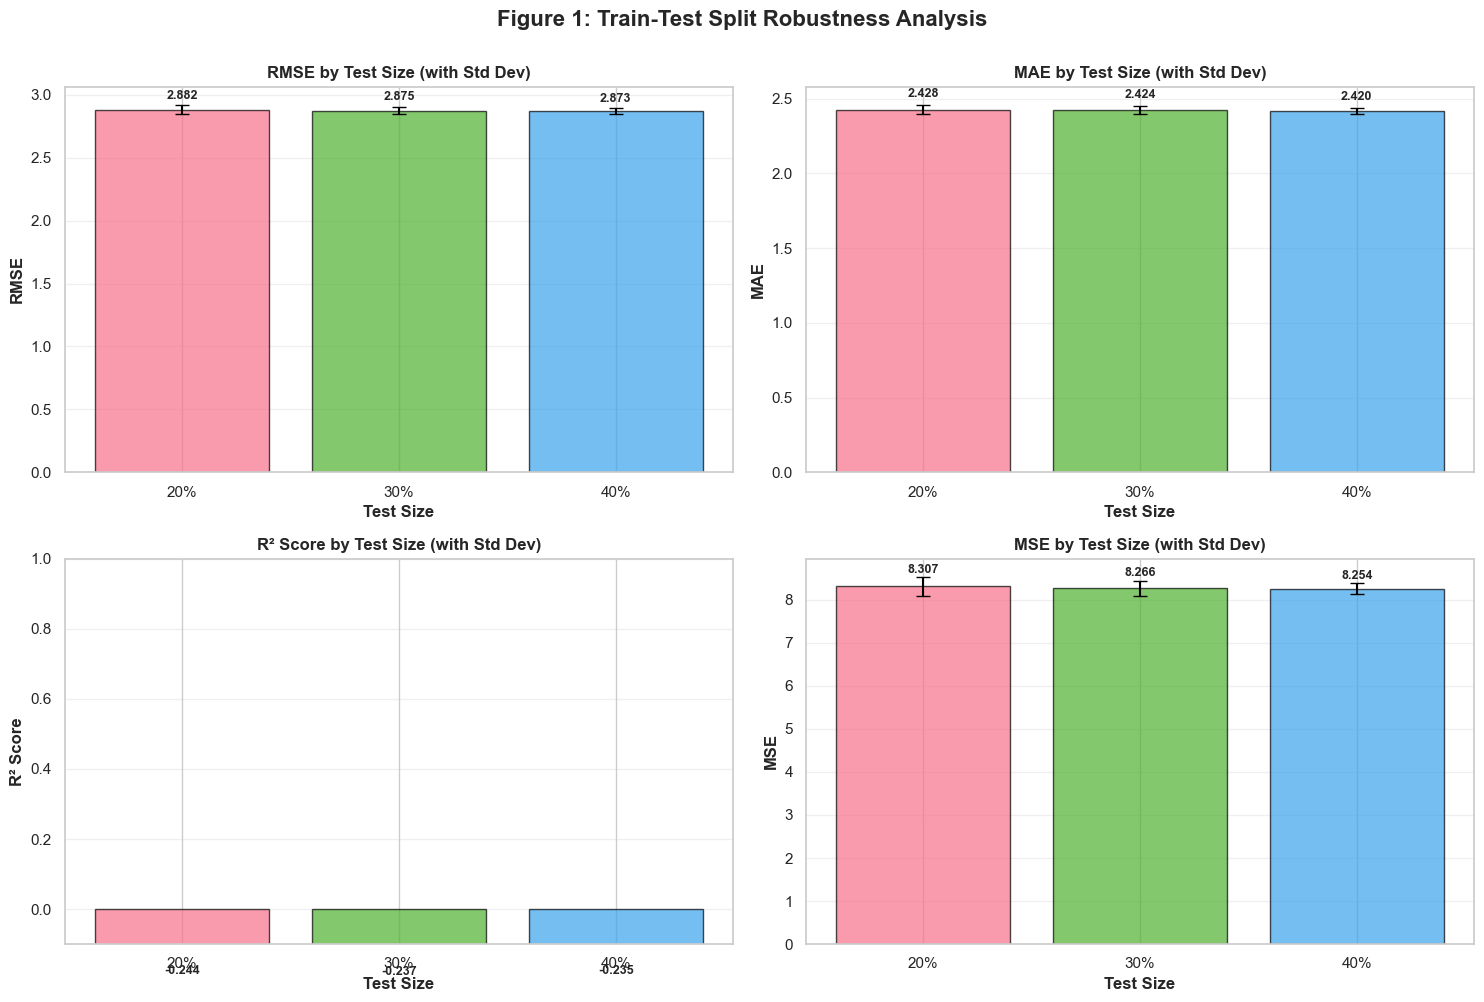

In [10]:
# ── VISUALIZATION 1: Train-Test Split Robustness ────────────────────────────
print('\n' + '=' * 80)
print('GENERATING VISUALIZATIONS')
print('=' * 80)

sns.set_theme(style='whitegrid', palette='husl', font_scale=1.0)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Figure 1: Train-Test Split Robustness Analysis', fontsize=16, fontweight='bold', y=1.00)

# Prepare data for plotting
tt_data_plot = tt_results_df.set_index('Test_Size')[['RMSE_Mean', 'RMSE_Std', 'MAE_Mean', 'MAE_Std', 'R2_Mean', 'R2_Std']]

# Plot 1: RMSE across different test sizes
ax1 = axes[0, 0]
test_sizes_labels = tt_results_df['Test_Size'].tolist()
rmse_means = tt_results_df['RMSE_Mean'].tolist()
rmse_stds = tt_results_df['RMSE_Std'].tolist()
colors_list = sns.color_palette('husl', len(test_sizes_labels))
bars1 = ax1.bar(test_sizes_labels, rmse_means, yerr=rmse_stds, capsize=5, color=colors_list, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Test Size', fontweight='bold')
ax1.set_ylabel('RMSE', fontweight='bold')
ax1.set_title('RMSE by Test Size (with Std Dev)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(rmse_means, rmse_stds)):
    ax1.text(i, m + s + 0.05, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2: MAE across different test sizes
ax2 = axes[0, 1]
mae_means = tt_results_df['MAE_Mean'].tolist()
mae_stds = tt_results_df['MAE_Std'].tolist()
bars2 = ax2.bar(test_sizes_labels, mae_means, yerr=mae_stds, capsize=5, color=colors_list, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Test Size', fontweight='bold')
ax2.set_ylabel('MAE', fontweight='bold')
ax2.set_title('MAE by Test Size (with Std Dev)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(mae_means, mae_stds)):
    ax2.text(i, m + s + 0.05, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3: R² Score across test sizes
ax3 = axes[1, 0]
r2_means = tt_results_df['R2_Mean'].tolist()
r2_stds = tt_results_df['R2_Std'].tolist()
bars3 = ax3.bar(test_sizes_labels, r2_means, yerr=r2_stds, capsize=5, color=colors_list, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Test Size', fontweight='bold')
ax3.set_ylabel('R² Score', fontweight='bold')
ax3.set_title('R² Score by Test Size (with Std Dev)', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([-0.1, 1.0])
for i, (m, s) in enumerate(zip(r2_means, r2_stds)):
    ax3.text(i, m + s + 0.03, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

# Plot 4: MSE across test sizes
ax4 = axes[1, 1]
mse_means = tt_results_df['MSE_Mean'].tolist()
mse_stds = tt_results_df['MSE_Std'].tolist()
bars4 = ax4.bar(test_sizes_labels, mse_means, yerr=mse_stds, capsize=5, color=colors_list, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Test Size', fontweight='bold')
ax4.set_ylabel('MSE', fontweight='bold')
ax4.set_title('MSE by Test Size (with Std Dev)', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(mse_means, mse_stds)):
    ax4.text(i, m + s + 0.1, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
fig_path = OUTPUT_DIR / 'RQ6_Figure1_TrainTestSplit.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'✅ Figure 1 saved: {fig_path}')
plt.show()


✅ Figure 2 saved: C:\Users\patil\Downloads\ML Project\output\RQ6_Figure2_CrossValidation.png


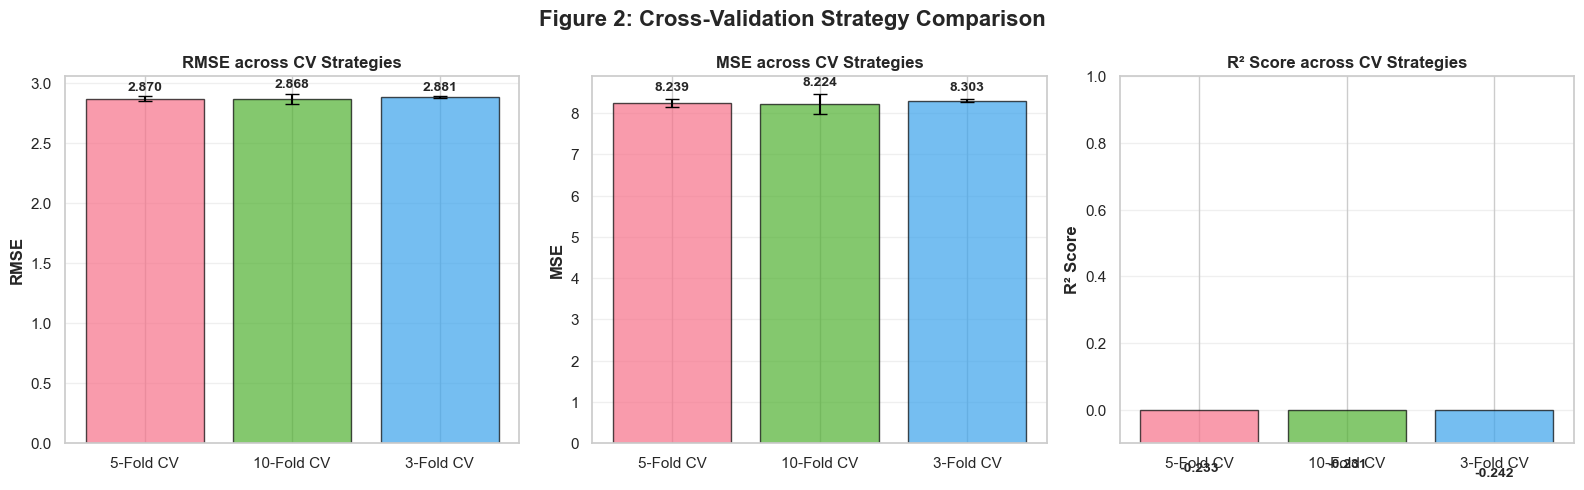

In [11]:
# ── VISUALIZATION 2: Cross-Validation Strategy Comparison ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 2: Cross-Validation Strategy Comparison', fontsize=16, fontweight='bold')

cv_labels = cv_results_df['CV_Strategy'].tolist()
colors_cv = sns.color_palette('husl', len(cv_labels))

# Plot 1: RMSE by CV strategy
ax1 = axes[0]
rmse_cv_means = cv_results_df['RMSE_Mean'].tolist()
rmse_cv_stds = cv_results_df['RMSE_Std'].tolist()
bars1 = ax1.bar(cv_labels, rmse_cv_means, yerr=rmse_cv_stds, capsize=5, color=colors_cv, alpha=0.7, edgecolor='black')
ax1.set_ylabel('RMSE', fontweight='bold')
ax1.set_title('RMSE across CV Strategies', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(rmse_cv_means, rmse_cv_stds)):
    ax1.text(i, m + s + 0.05, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

# Plot 2: MSE by CV strategy
ax2 = axes[1]
mse_cv_means = cv_results_df['MSE_Mean'].tolist()
mse_cv_stds = cv_results_df['MSE_Std'].tolist()
bars2 = ax2.bar(cv_labels, mse_cv_means, yerr=mse_cv_stds, capsize=5, color=colors_cv, alpha=0.7, edgecolor='black')
ax2.set_ylabel('MSE', fontweight='bold')
ax2.set_title('MSE across CV Strategies', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(mse_cv_means, mse_cv_stds)):
    ax2.text(i, m + s + 0.2, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

# Plot 3: R² by CV strategy
ax3 = axes[2]
r2_cv_means = cv_results_df['R2_Mean'].tolist()
r2_cv_stds = cv_results_df['R2_Std'].tolist()
bars3 = ax3.bar(cv_labels, r2_cv_means, yerr=r2_cv_stds, capsize=5, color=colors_cv, alpha=0.7, edgecolor='black')
ax3.set_ylabel('R² Score', fontweight='bold')
ax3.set_title('R² Score across CV Strategies', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([-0.1, 1.0])
for i, (m, s) in enumerate(zip(r2_cv_means, r2_cv_stds)):
    ax3.text(i, m + s + 0.03, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
fig_path = OUTPUT_DIR / 'RQ6_Figure2_CrossValidation.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'✅ Figure 2 saved: {fig_path}')
plt.show()


✅ Figure 3 saved: C:\Users\patil\Downloads\ML Project\output\RQ6_Figure3_NoisePerturbation.png


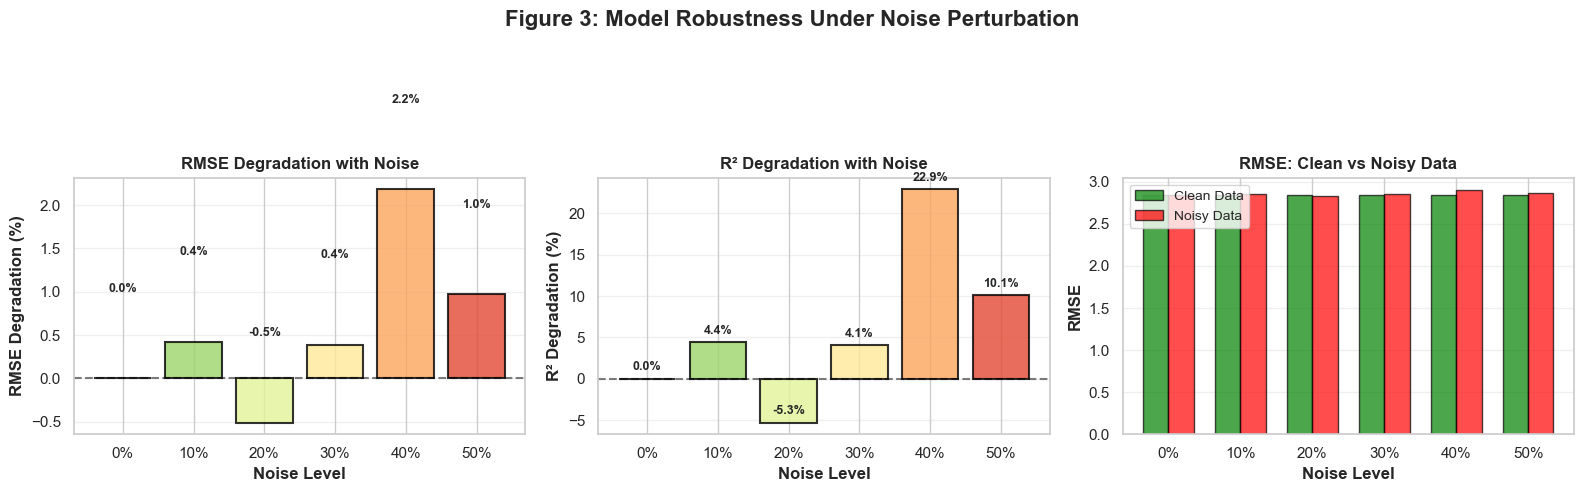

In [12]:
# ── VISUALIZATION 3: Data Perturbation - Noise Injection Impact ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 3: Model Robustness Under Noise Perturbation', fontsize=16, fontweight='bold')

noise_labels = pert_results_df['Noise_Level_%'].tolist()
colors_pert = sns.color_palette('RdYlGn_r', len(noise_labels))

# Plot 1: RMSE degradation with noise
ax1 = axes[0]
rmse_degradation_noise = pert_results_df['RMSE_Degradation_%'].tolist()
bars1 = ax1.bar(noise_labels, rmse_degradation_noise, color=colors_pert, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Noise Level', fontweight='bold')
ax1.set_ylabel('RMSE Degradation (%)', fontweight='bold')
ax1.set_title('RMSE Degradation with Noise', fontweight='bold')
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(rmse_degradation_noise):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Plot 2: R² degradation with noise
ax2 = axes[1]
r2_degradation_noise = pert_results_df['R2_Degradation_%'].tolist()
bars2 = ax2.bar(noise_labels, r2_degradation_noise, color=colors_pert, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Noise Level', fontweight='bold')
ax2.set_ylabel('R² Degradation (%)', fontweight='bold')
ax2.set_title('R² Degradation with Noise', fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(r2_degradation_noise):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Plot 3: Absolute performance metrics with noise
ax3 = axes[2]
rmse_noisy = pert_results_df['RMSE_Noisy'].tolist()
rmse_clean = pert_results_df['RMSE_Clean'].tolist()
x_pos = np.arange(len(noise_labels))
width = 0.35
bars_clean = ax3.bar(x_pos - width/2, rmse_clean, width, label='Clean Data', color='green', alpha=0.7, edgecolor='black')
bars_noisy = ax3.bar(x_pos + width/2, rmse_noisy, width, label='Noisy Data', color='red', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Noise Level', fontweight='bold')
ax3.set_ylabel('RMSE', fontweight='bold')
ax3.set_title('RMSE: Clean vs Noisy Data', fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(noise_labels)
ax3.legend(fontsize=10, loc='upper left')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'RQ6_Figure3_NoisePerturbation.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'✅ Figure 3 saved: {fig_path}')
plt.show()


✅ Figure 4 saved: C:\Users\patil\Downloads\ML Project\output\RQ6_Figure4_MissingDataPerturbation.png


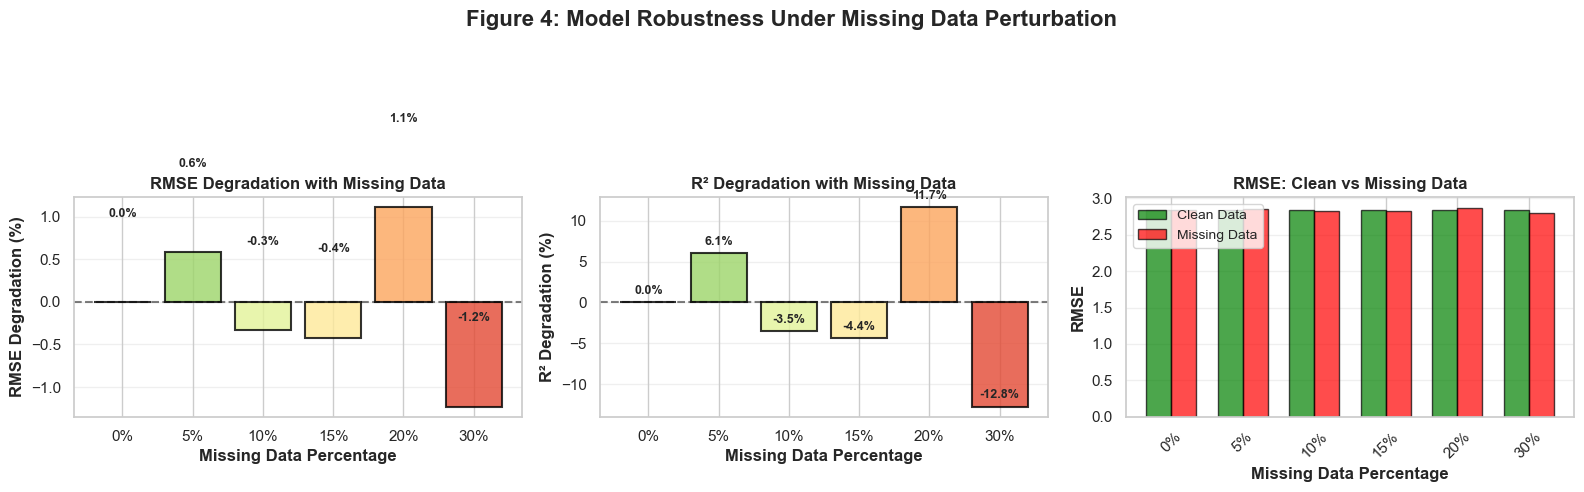

In [13]:
# ── VISUALIZATION 4: Data Perturbation - Missing Data Impact ────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 4: Model Robustness Under Missing Data Perturbation', fontsize=16, fontweight='bold')

missing_labels = miss_results_df['Missing_Data_%'].tolist()
colors_miss = sns.color_palette('RdYlGn_r', len(missing_labels))

# Plot 1: RMSE degradation with missing data
ax1 = axes[0]
rmse_degradation_miss = miss_results_df['RMSE_Degradation_%'].tolist()
bars1 = ax1.bar(missing_labels, rmse_degradation_miss, color=colors_miss, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Missing Data Percentage', fontweight='bold')
ax1.set_ylabel('RMSE Degradation (%)', fontweight='bold')
ax1.set_title('RMSE Degradation with Missing Data', fontweight='bold')
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(rmse_degradation_miss):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Plot 2: R² degradation with missing data
ax2 = axes[1]
r2_degradation_miss = miss_results_df['R2_Degradation_%'].tolist()
bars2 = ax2.bar(missing_labels, r2_degradation_miss, color=colors_miss, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Missing Data Percentage', fontweight='bold')
ax2.set_ylabel('R² Degradation (%)', fontweight='bold')
ax2.set_title('R² Degradation with Missing Data', fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(r2_degradation_miss):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Plot 3: Absolute performance metrics with missing data
ax3 = axes[2]
rmse_missing = miss_results_df['RMSE_Missing'].tolist()
rmse_clean_miss = miss_results_df['RMSE_Clean'].tolist()
x_pos = np.arange(len(missing_labels))
width = 0.35
bars_clean = ax3.bar(x_pos - width/2, rmse_clean_miss, width, label='Clean Data', color='green', alpha=0.7, edgecolor='black')
bars_missing = ax3.bar(x_pos + width/2, rmse_missing, width, label='Missing Data', color='red', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Missing Data Percentage', fontweight='bold')
ax3.set_ylabel('RMSE', fontweight='bold')
ax3.set_title('RMSE: Clean vs Missing Data', fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(missing_labels, rotation=45)
ax3.legend(fontsize=10, loc='upper left')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'RQ6_Figure4_MissingDataPerturbation.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'✅ Figure 4 saved: {fig_path}')
plt.show()


✅ Figure 5 saved: C:\Users\patil\Downloads\ML Project\output\RQ6_Figure5_MentalHealthByGender.png


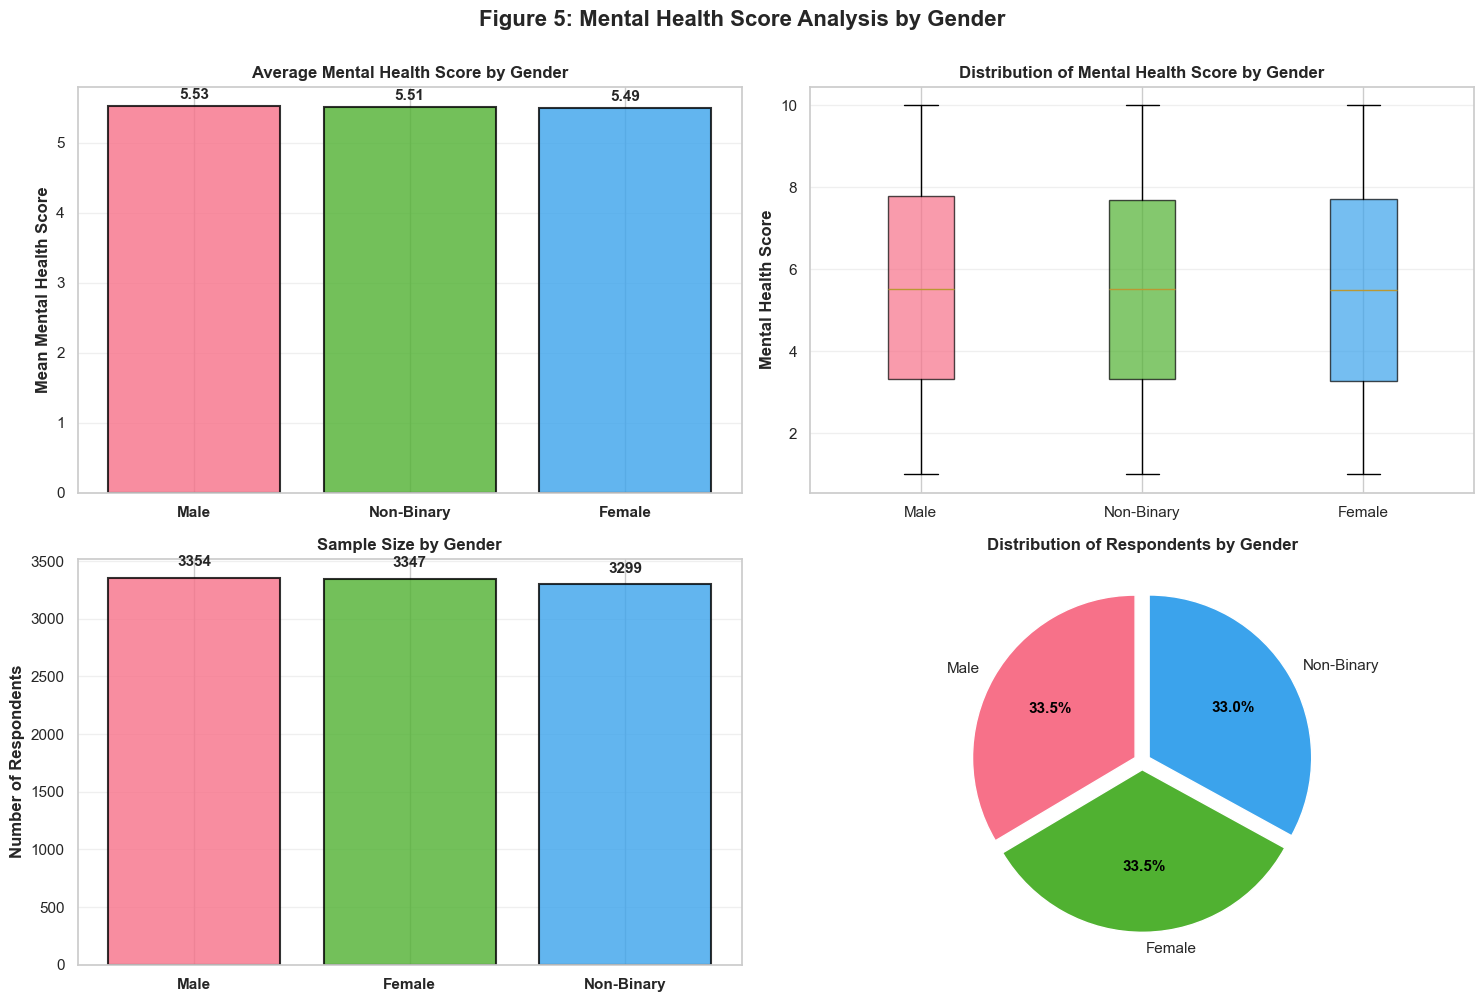

In [14]:
# ── VISUALIZATION 5: Mental Health Score by Gender ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Figure 5: Mental Health Score Analysis by Gender', fontsize=16, fontweight='bold', y=1.00)

gender_means = gender_stats['Mean'].sort_values(ascending=False)
gender_colors = sns.color_palette('husl', len(gender_means))

# Plot 1: Bar chart of mean scores
ax1 = axes[0, 0]
bars = ax1.bar(range(len(gender_means)), gender_means.values, color=gender_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(gender_means)))
ax1.set_xticklabels(gender_means.index, fontweight='bold')
ax1.set_ylabel('Mean Mental Health Score', fontweight='bold')
ax1.set_title('Average Mental Health Score by Gender', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(gender_means.values):
    ax1.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

# Plot 2: Box plot of scores by gender
ax2 = axes[0, 1]
gender_data = [df[df['gender'] == g]['mental_health_score'].values for g in gender_means.index]
bp = ax2.boxplot(gender_data, labels=gender_means.index, patch_artist=True)
for patch, color in zip(bp['boxes'], gender_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Mental Health Score', fontweight='bold')
ax2.set_title('Distribution of Mental Health Score by Gender', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Count distribution
ax3 = axes[1, 0]
gender_counts = gender_stats['Count'].sort_values(ascending=False)
bars = ax3.bar(range(len(gender_counts)), gender_counts.values, color=gender_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_xticks(range(len(gender_counts)))
ax3.set_xticklabels(gender_counts.index, fontweight='bold')
ax3.set_ylabel('Number of Respondents', fontweight='bold')
ax3.set_title('Sample Size by Gender', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(gender_counts.values):
    ax3.text(i, v + 100, f'{int(v)}', ha='center', fontweight='bold', fontsize=11)

# Plot 4: Percentage pie chart
ax4 = axes[1, 1]
gender_pct = gender_stats['Percentage'].sort_values(ascending=False)
wedges, texts, autotexts = ax4.pie(gender_pct.values, labels=gender_pct.index, autopct='%1.1f%%',
                                     colors=gender_colors, startangle=90, explode=[0.05]*len(gender_pct))
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
ax4.set_title('Distribution of Respondents by Gender', fontweight='bold')

plt.tight_layout()
fig_path = OUTPUT_DIR / 'RQ6_Figure5_MentalHealthByGender.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'✅ Figure 5 saved: {fig_path}')
plt.show()


In [16]:
# ── EXPORT ALL RESULTS ────────────────────────────────────────────────────────
print('\n' + '=' * 80)
print('📁 EXPORTING ALL ANALYSIS RESULTS')
print('=' * 80)

# Create a master results file
master_results = {
    'Analysis_Type': [],
    'Metric': [],
    'Value': []
}

# Train-Test Results
for idx, row in tt_results_df.iterrows():
    for col in ['RMSE_Mean', 'RMSE_Std', 'MAE_Mean', 'MAE_Std', 'R2_Mean', 'R2_Std']:
        master_results['Analysis_Type'].append('Train-Test Split')
        master_results['Metric'].append(f"{row['Test_Size']} - {col}")
        master_results['Value'].append(row[col])

# CV Results
for idx, row in cv_results_df.iterrows():
    for col in ['RMSE_Mean', 'RMSE_Std', 'R2_Mean', 'R2_Std']:
        master_results['Analysis_Type'].append('Cross-Validation')
        master_results['Metric'].append(f"{row['CV_Strategy']} - {col}")
        master_results['Value'].append(row[col])

# Perturbation Results
for idx, row in pert_results_df.iterrows():
    for col in ['RMSE_Degradation_%', 'R2_Degradation_%']:
        master_results['Analysis_Type'].append('Noise Perturbation')
        master_results['Metric'].append(f"{row['Noise_Level_%']} - {col}")
        master_results['Value'].append(row[col])

for idx, row in miss_results_df.iterrows():
    for col in ['RMSE_Degradation_%', 'R2_Degradation_%']:
        master_results['Analysis_Type'].append('Missing Data Perturbation')
        master_results['Metric'].append(f"{row['Missing_Data_%']} - {col}")
        master_results['Value'].append(row[col])

master_df = pd.DataFrame(master_results)
master_csv_path = OUTPUT_DIR / 'RQ6_Master_Results.csv'
master_df.to_csv(master_csv_path, index=False)

print(f'\n✅ All Files Generated:')
print(f'   1. {tt_csv_path.name}')
print(f'   2. {cv_csv_path.name}')
print(f'   3. {pert_csv_path.name}')
print(f'   4. {miss_csv_path.name}')
print(f'   5. {gender_csv_path.name}')
print(f'   6. {master_csv_path.name}')
print(f'\n✅ Visualizations Generated:')
print(f'   1. RQ6_Figure1_TrainTestSplit.png')
print(f'   2. RQ6_Figure2_CrossValidation.png')
print(f'   3. RQ6_Figure3_NoisePerturbation.png')
print(f'   4. RQ6_Figure4_MissingDataPerturbation.png')
print(f'   5. RQ6_Figure5_MentalHealthByGender.png')
print(f'\n✅ Output Directory: {OUTPUT_DIR}')

print('\n' + '=' * 80)
print('✅ RQ6 ANALYSIS COMPLETE!')
print('=' * 80)



📁 EXPORTING ALL ANALYSIS RESULTS

✅ All Files Generated:
   1. RQ6_TrainTestSplit_Results.csv
   2. RQ6_CrossValidation_Results.csv
   3. RQ6_Perturbation_Noise_Results.csv
   4. RQ6_Perturbation_Missing_Results.csv
   5. RQ6_MentalHealth_ByGender_Table.csv
   6. RQ6_Master_Results.csv

✅ Visualizations Generated:
   1. RQ6_Figure1_TrainTestSplit.png
   2. RQ6_Figure2_CrossValidation.png
   3. RQ6_Figure3_NoisePerturbation.png
   4. RQ6_Figure4_MissingDataPerturbation.png
   5. RQ6_Figure5_MentalHealthByGender.png

✅ Output Directory: C:\Users\patil\Downloads\ML Project\output

✅ RQ6 ANALYSIS COMPLETE!
